# 0. Data Layers Overview

Этот notebook показывает только **clean data architecture** проекта.

Здесь мы сознательно не используем `benchmarks` и не строим legacy derived panels. Цель notebook — показать, как устроены и как используются два базовых слоя:

1. `raw` — source-of-truth таблицы почти без research-интерпретации;
2. `canonical` — нормализованный и более стабильный слой для downstream representations.

Legacy benchmark construction живёт отдельно в `/benchmarks` и не является частью этого notebook.

## Импорты и конфигурация

Ниже только базовые imports для current data layers.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from polymarket_research import PolymarketDataset
from polymarket_research.data import DataBundle
from polymarket_research.data.canonical import CanonicalDatasetBuilder
from polymarket_research.data.raw import RawExternalCovariates

REPO_ROOT = Path('/Users/sneddy/research/polymarket_research')
RAW_CACHE_DIR = REPO_ROOT / 'research_notebooks' / 'running_artefacts_new'
CANONICAL_CACHE_DIR = RAW_CACHE_DIR / 'canonical_dataset'

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', None)

## Загружаем raw layer

Raw layer поднимается из parquet snapshot, который был ранее сохранён из SQLite. Это current source-of-truth view для research notebooks.

In [ ]:
DOMAINS = ('politics', 'geopolitics', 'technology', 'finance_economy')
USE_PARQUET_CACHE = False
# USE_PARQUET_CACHE = (RAW_CACHE_DIR / 'markets.parquet').exists() and (RAW_CACHE_DIR / 'probabilities.parquet').exists()

if USE_PARQUET_CACHE:
    print('Loading from parquet cache')
    raw_dataset = PolymarketDataset.from_parquet(RAW_CACHE_DIR)
    raw_source_label = f'parquet cache: {RAW_CACHE_DIR}'
else:
    raw_dataset = PolymarketDataset(
        domains=DOMAINS,
        max_markets_per_domain=800,
        min_probability_rows=288,
    )
    raw_dataset.load()
    raw_dataset.save(RAW_CACHE_DIR)
    raw_source_label = f'sqlite: {raw_dataset.db_path}'

raw_external = RawExternalCovariates().load()

print('Raw source:', raw_source_label)
print('External cached path:', raw_external.path)

markets = raw_dataset.markets.copy()
probabilities = raw_dataset.probabilities.copy()

display(raw_dataset.summary())
display(raw_external.summary())

Raw source: sqlite: /Users/sneddy/research/polymarket_research/db/resolved_probability_dataset.sqlite
External cached path: /Users/sneddy/research/polymarket_research/cached_data/external_covariates


,name,loaded,rows,cols
0,markets,True,2905,25
1,probabilities,True,50918460,7


,name,loaded,rows,cols
0,external_covariates,True,263808,19


: 

## Quick inspection of raw tables

Эта секция нужна, чтобы быстро увидеть, что именно лежит в raw layer и какие поля уже доступны без дополнительной интерпретации.

In [4]:
display(Markdown('### Raw markets'))
display(raw_dataset.short_markets.head(10))

display(Markdown('### Raw external covariates'))
display(raw_external.short_covariates.head(10))

### Raw markets

,market_id,question,primary_domain,active,closed,resolved,probability_start_utc,probability_end_utc,final_outcome
0,546814,Will Zelenskyy wear a suit before July?,politics,1,1,True,2025-05-22 22:55:00+00:00,2025-07-09 00:35:00+00:00,No
1,680392,US government shutdown Saturday?,politics,1,1,True,2025-11-13 15:35:00+00:00,2026-02-04 00:40:00+00:00,Yes
2,538932,Will Zohran Mamdani win the 2025 NYC mayoral election?,politics,1,1,True,2025-04-22 18:30:00+00:00,2025-11-05 05:50:00+00:00,Yes
3,529278,Will Frances Fitzgerald win the Irish Presidential Election?,politics,1,1,True,2025-03-21 12:40:00+00:00,2025-10-25 21:20:00+00:00,No
4,519075,Will Hunor Kelemen win the Romanian presidential election?,politics,1,1,True,2025-01-17 23:15:00+00:00,2025-05-16 20:50:00+00:00,No
5,538930,Will Curtis Sliwa win the 2025 NYC mayoral election?,politics,1,1,True,2025-04-22 18:10:00+00:00,2025-11-05 05:30:00+00:00,No
6,519068,Will Nicușor Dan win the Romanian presidential election?,politics,1,1,True,2025-01-17 23:00:00+00:00,2025-05-19 02:05:00+00:00,Yes
7,538931,Will Jim Walden win the 2025 NYC mayoral election?,politics,1,1,True,2025-04-22 18:15:00+00:00,2025-11-05 05:55:00+00:00,No
8,538929,Will Andrew Cuomo win the 2025 NYC mayoral election?,politics,1,1,True,2025-04-22 16:20:00+00:00,2025-11-05 05:55:00+00:00,No
9,519066,Will George Simion win the Romanian presidential election?,politics,1,1,True,2025-01-17 23:00:00+00:00,2025-05-19 03:00:00+00:00,No


### Raw external covariates

,series_id,timestamp_utc,close_timestamp_utc,open,high,low,close,volume,quote_asset_volume,trade_count
0,btc_usd,2025-01-01 00:00:00+00:00,2025-01-01 00:04:59.999000+00:00,93576.00,93702.15,93537.50,93661.20,45.94160,4.301907e+06,7448
1,btc_usd,2025-01-01 00:05:00+00:00,2025-01-01 00:09:59.999000+00:00,93661.20,93678.02,93600.00,93607.10,71.94585,6.736121e+06,4165
2,btc_usd,2025-01-01 00:10:00+00:00,2025-01-01 00:14:59.999000+00:00,93607.10,93656.19,93489.03,93656.18,57.96928,5.423766e+06,8175
3,btc_usd,2025-01-01 00:15:00+00:00,2025-01-01 00:19:59.999000+00:00,93656.19,93840.05,93614.95,93796.35,39.74456,3.727084e+06,8031
4,btc_usd,2025-01-01 00:20:00+00:00,2025-01-01 00:24:59.999000+00:00,93796.35,93898.05,93707.81,93740.00,38.38053,3.600685e+06,10064
5,btc_usd,2025-01-01 00:25:00+00:00,2025-01-01 00:29:59.999000+00:00,93740.00,93761.90,93721.00,93761.90,17.29240,1.620905e+06,2383
6,btc_usd,2025-01-01 00:30:00+00:00,2025-01-01 00:34:59.999000+00:00,93761.90,93963.67,93761.89,93882.92,41.20105,3.868314e+06,9193
7,btc_usd,2025-01-01 00:35:00+00:00,2025-01-01 00:39:59.999000+00:00,93882.91,93924.61,93836.61,93909.03,29.61201,2.779744e+06,7252
8,btc_usd,2025-01-01 00:40:00+00:00,2025-01-01 00:44:59.999000+00:00,93909.03,93952.97,93885.00,93885.01,23.55110,2.211784e+06,5380
9,btc_usd,2025-01-01 00:45:00+00:00,2025-01-01 00:49:59.999000+00:00,93885.00,93977.98,93864.44,93977.97,16.06620,1.509070e+06,3953


## Raw layer: weekly dollar volume proxy

В raw markets нет честного trade-timestamped dollar volume, но есть market-level `volume_num`. Поэтому ниже мы смотрим грубый proxy: суммарный `volume_num`, агрегированный по неделе создания рынка. Это уже ближе к экономической активности, чем `probability_rows`.

,week,total_volume_usd
55,2026-01-19,1.059595e+08
56,2026-01-26,2.470006e+08
57,2026-02-02,1.542898e+08
58,2026-02-09,1.114507e+08
59,2026-02-16,1.968848e+08
60,2026-02-23,1.103913e+08
61,2026-03-02,4.303012e+07
62,2026-03-09,2.285962e+07
63,2026-03-16,2.487024e+07
64,2026-03-23,1.926963e+07


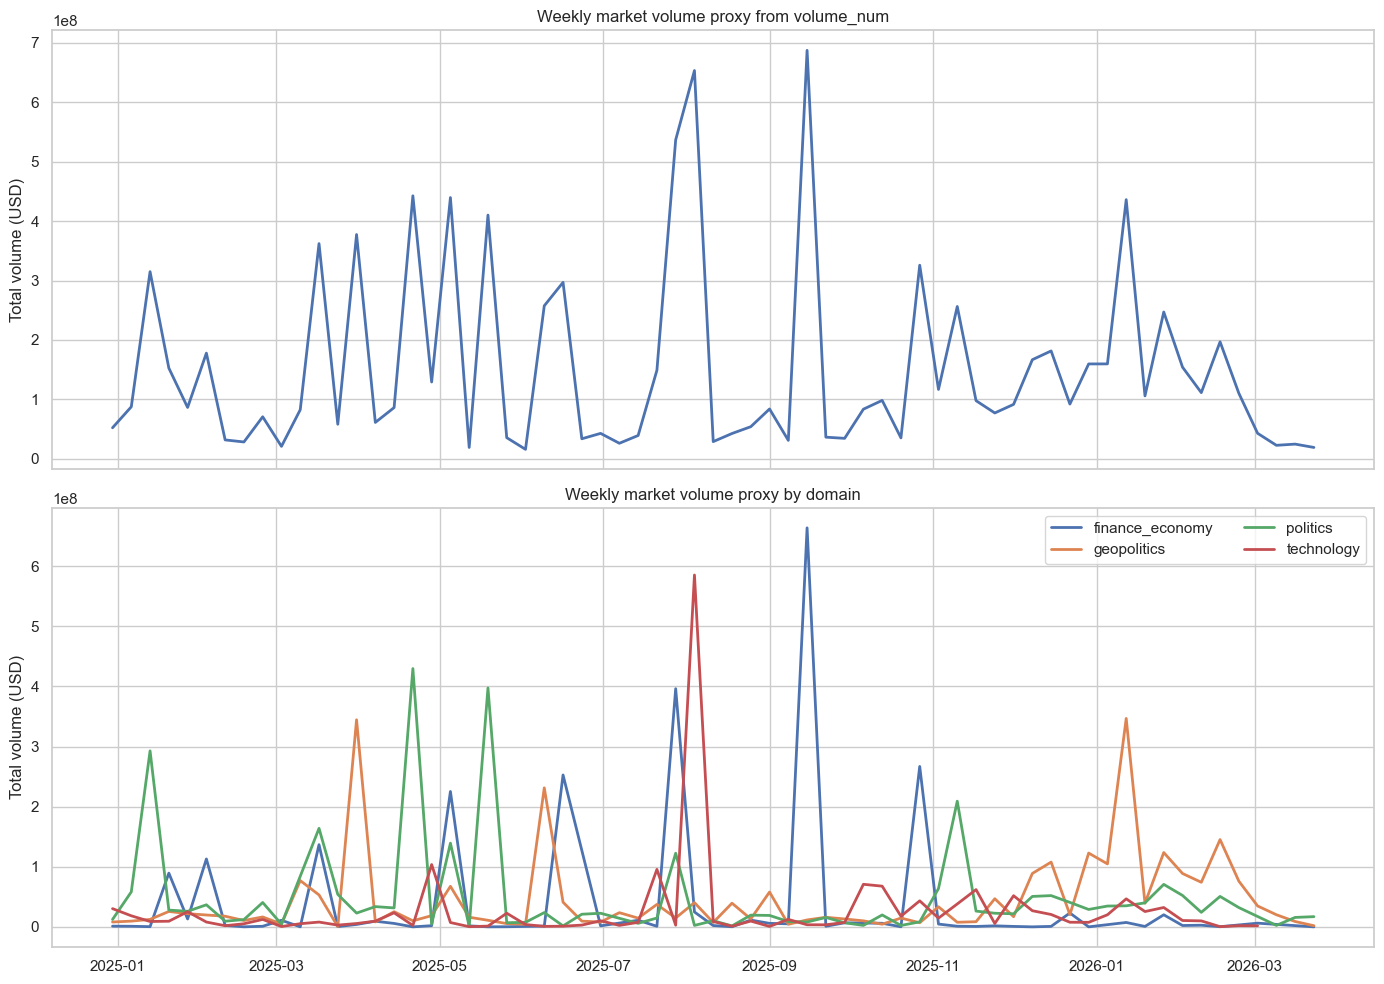

In [5]:
created_week = markets['created_at'].dt.tz_localize(None).dt.to_period('W').dt.start_time

weekly_volume = (
    markets.assign(week=created_week, volume_num=markets['volume_num'].fillna(0.0))
    .groupby('week', as_index=False)['volume_num']
    .sum()
    .rename(columns={'volume_num': 'total_volume_usd'})
)

weekly_volume_by_domain = (
    markets.assign(week=created_week, volume_num=markets['volume_num'].fillna(0.0))
    .groupby(['week', 'primary_domain'], as_index=False)['volume_num']
    .sum()
    .rename(columns={'volume_num': 'total_volume_usd'})
)

display(weekly_volume.tail(10))

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
axes[0].plot(weekly_volume['week'], weekly_volume['total_volume_usd'], linewidth=2, color='#4c72b0')
axes[0].set_title('Weekly market volume proxy from volume_num')
axes[0].set_ylabel('Total volume (USD)')

for domain, frame in weekly_volume_by_domain.groupby('primary_domain'):
    axes[1].plot(frame['week'], frame['total_volume_usd'], linewidth=2, label=domain)
axes[1].set_title('Weekly market volume proxy by domain')
axes[1].set_ylabel('Total volume (USD)')
axes[1].legend(ncol=2)
plt.tight_layout()
plt.show()

## Raw layer: new markets over time

Перед графиком active markets полезно посмотреть на более простой поток: сколько новых вопросов стартует каждую неделю. Недельная агрегация сглаживает дневной шум и меньше искажается хвостом долгоживущих рынков.


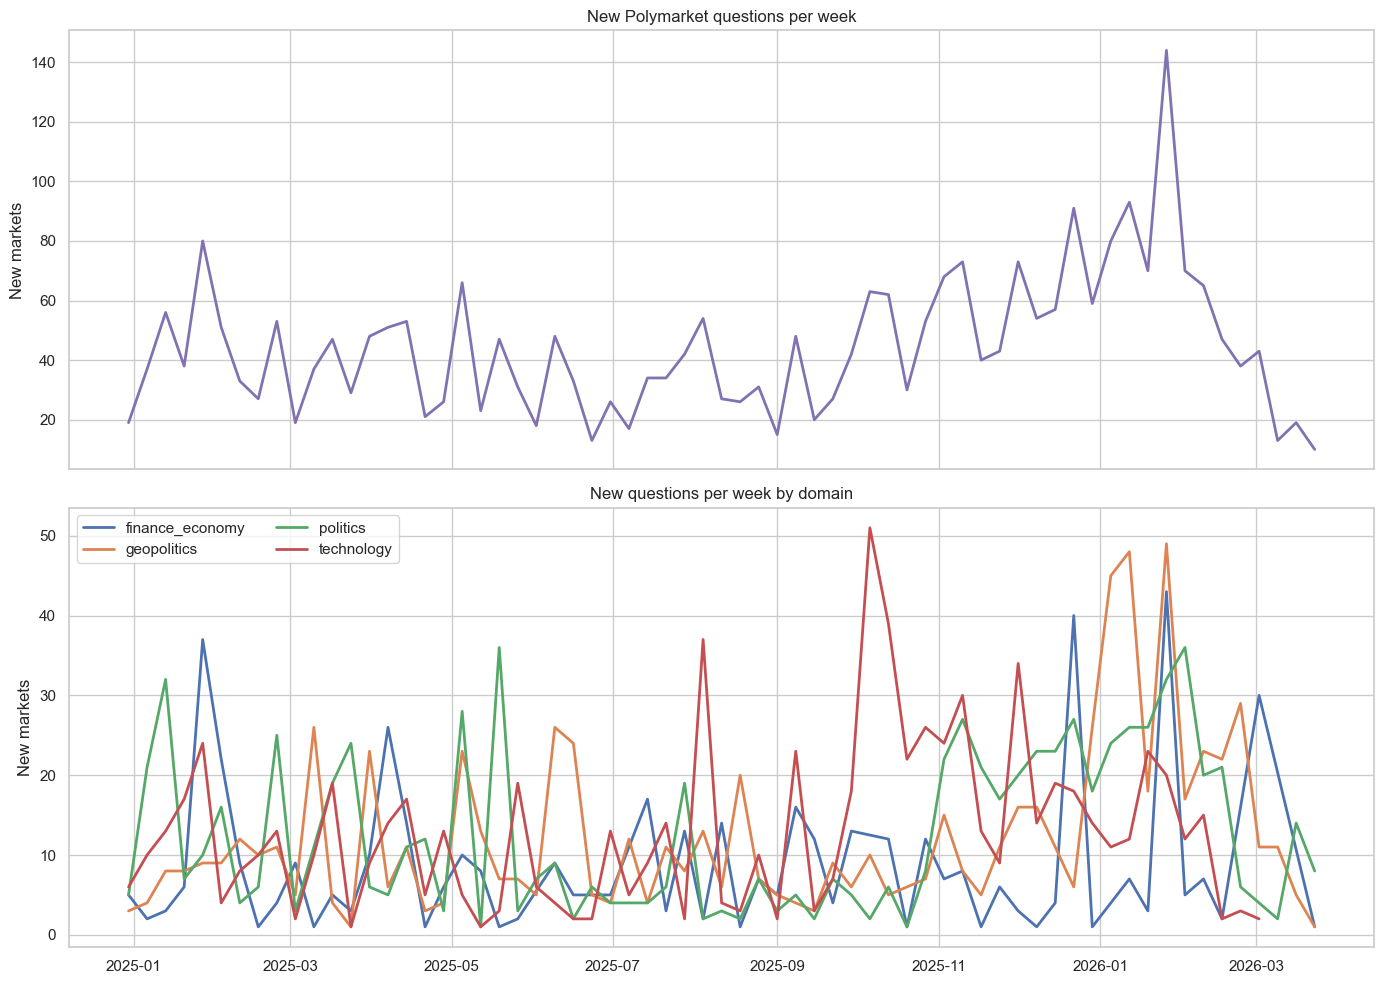

In [6]:
created_week = markets['created_at'].dt.tz_localize(None).dt.to_period('W').dt.start_time

new_weekly = (
    markets.assign(week=created_week)
    .groupby('week', as_index=False)
    .size()
    .rename(columns={'size': 'new_markets'})
)

new_weekly_by_domain = (
    markets.assign(week=created_week)
    .groupby(['week', 'primary_domain'], as_index=False)
    .size()
    .rename(columns={'size': 'new_markets'})
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
axes[0].plot(new_weekly['week'], new_weekly['new_markets'], linewidth=2, color='#8172b2')
axes[0].set_title('New Polymarket questions per week')
axes[0].set_ylabel('New markets')

for domain, frame in new_weekly_by_domain.groupby('primary_domain'):
    axes[1].plot(frame['week'], frame['new_markets'], linewidth=2, label=domain)
axes[1].set_title('New questions per week by domain')
axes[1].set_ylabel('New markets')
axes[1].legend(ncol=2)
plt.tight_layout()
plt.show()


## Raw layer: active markets over time

Ниже мы используем только raw metadata (`created_at`, `end_date`) и считаем, сколько рынков было активным в каждый день. Это хороший sanity check жизненного цикла рынков.

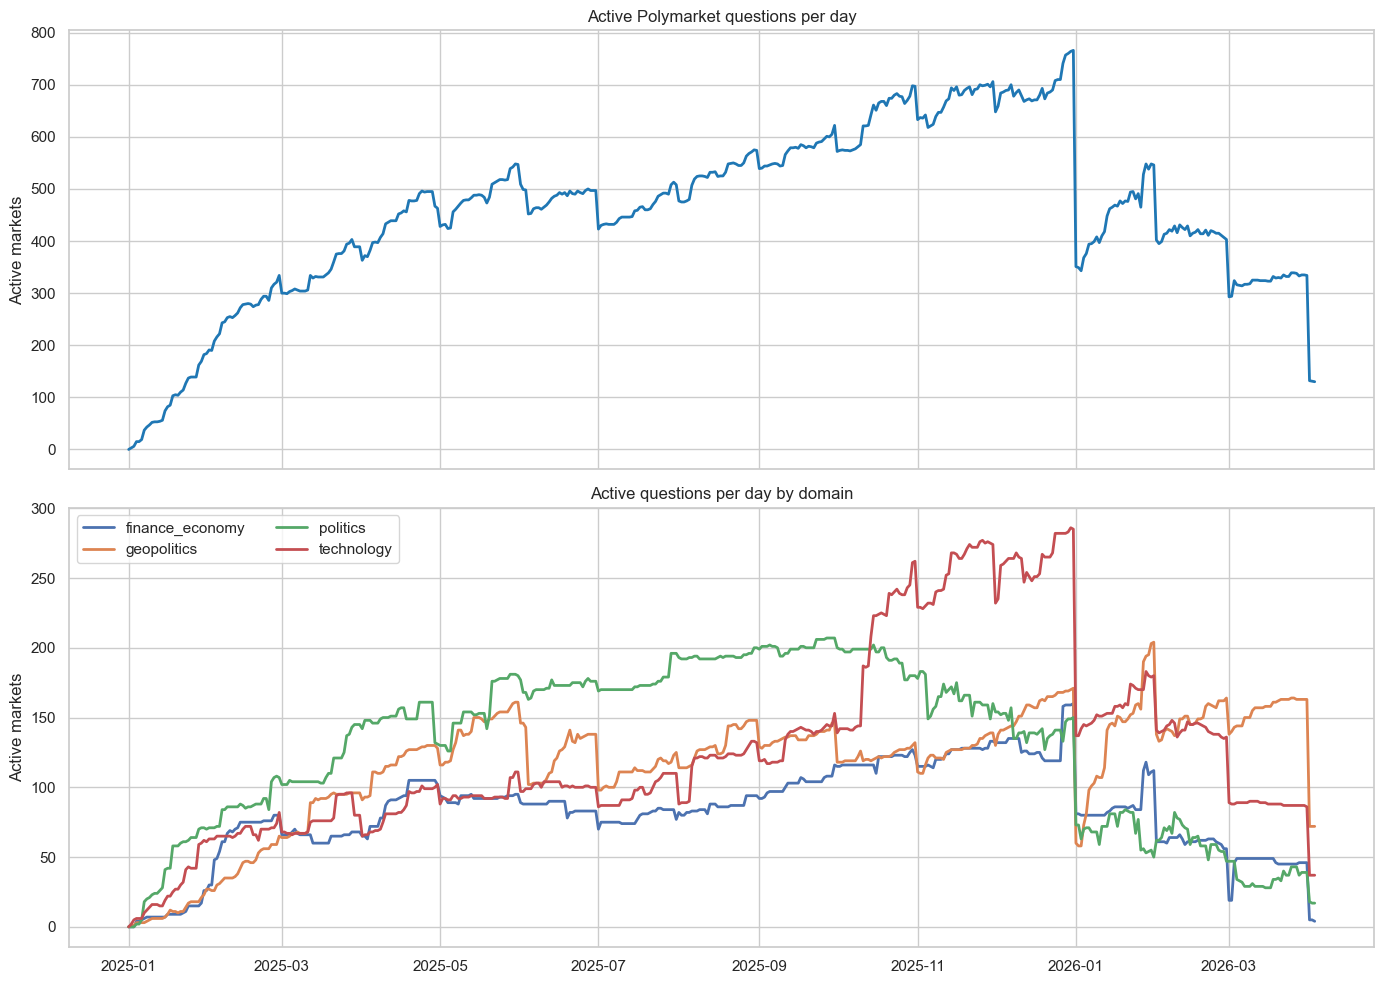

In [7]:
def build_active_markets_daily(markets: pd.DataFrame, by_domain: bool = False) -> pd.DataFrame:
    """Count how many markets are active on each day using created/end timestamps."""
    start = markets['created_at'].min().floor('D')
    end = markets['end_date'].max().floor('D')
    if 'synced_at_utc' in markets.columns:
        end = min(end, markets['synced_at_utc'].max().floor('D'))
    days = pd.date_range(start, end, freq='D', tz='UTC')

    rows = []
    group_cols = ['primary_domain'] if by_domain else [None]
    grouped = markets.groupby('primary_domain') if by_domain else [(None, markets)]
    for key, frame in grouped:
        for day in days:
            active_count = int(((frame['created_at'] <= day) & (frame['end_date'] >= day)).sum())
            row = {'day': day, 'active_markets': active_count}
            if by_domain:
                row['primary_domain'] = key
            rows.append(row)
    return pd.DataFrame(rows)

active_daily = build_active_markets_daily(markets)
active_daily_by_domain = build_active_markets_daily(markets, by_domain=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
axes[0].plot(active_daily['day'], active_daily['active_markets'], linewidth=2, color='#1f77b4')
axes[0].set_title('Active Polymarket questions per day')
axes[0].set_ylabel('Active markets')

for domain, frame in active_daily_by_domain.groupby('primary_domain'):
    axes[1].plot(frame['day'], frame['active_markets'], linewidth=2, label=domain)
axes[1].set_title('Active questions per day by domain')
axes[1].set_ylabel('Active markets')
axes[1].legend(ncol=2)
plt.tight_layout()
plt.show()

## Raw layer: traded dollar volume

Теперь смотрим не на число строк, а на денежную активность в `probabilities`: weekly сумму `total_size`. Это уже ближе к реальному торговому потоку, чем просто плотность временного ряда.

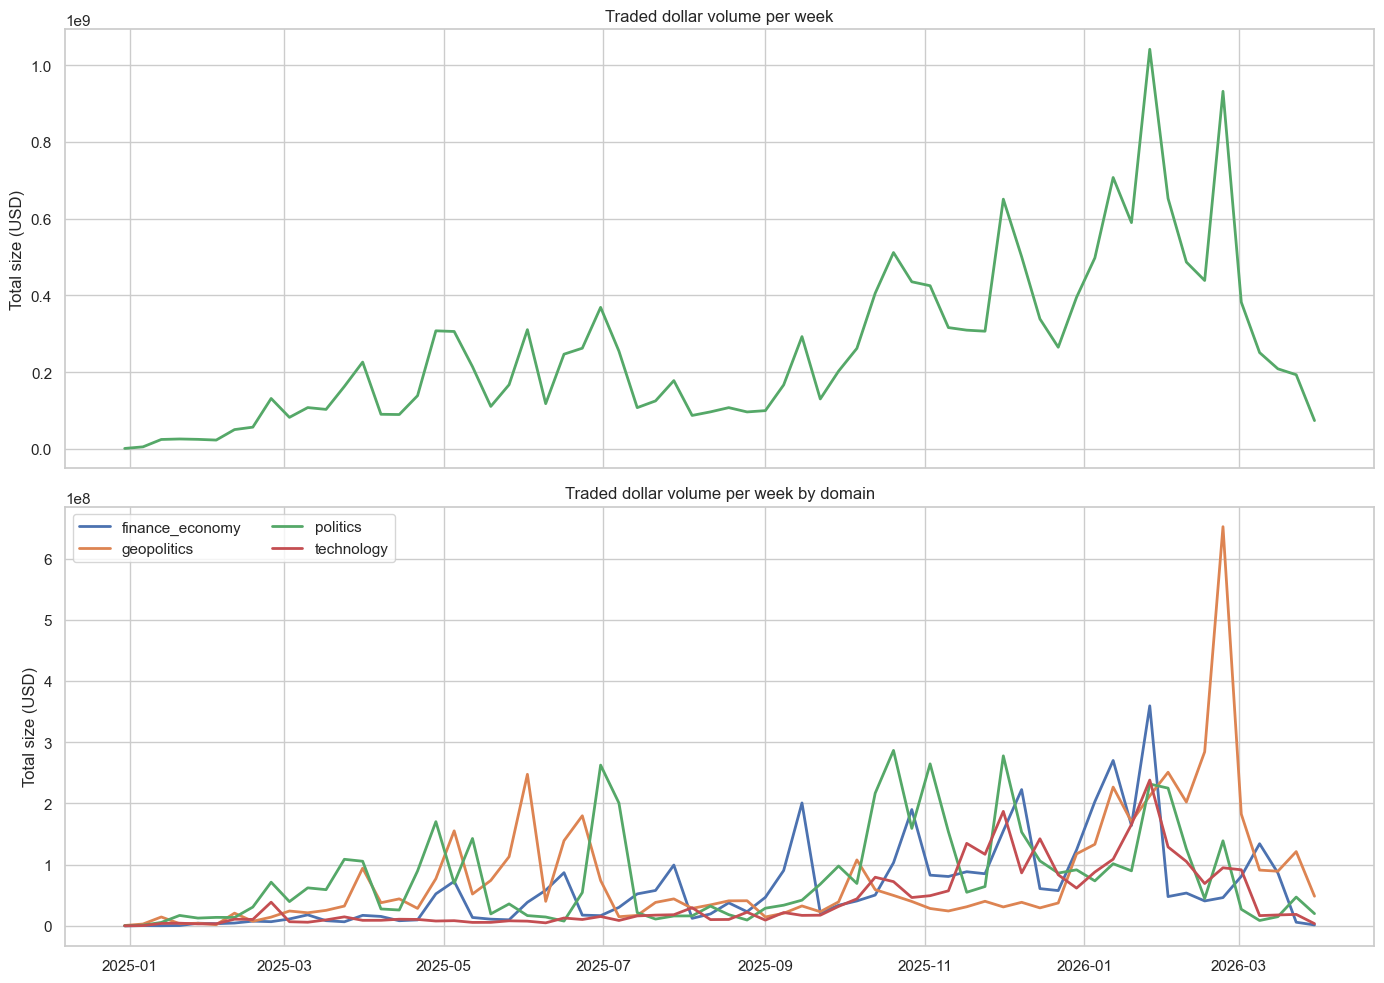

In [8]:
probability_week = probabilities['timestamp_utc'].dt.tz_localize(None).dt.to_period('W').dt.start_time

probability_weekly = (
    probabilities.assign(week=probability_week, total_size=probabilities['total_size'].fillna(0.0))
    .groupby('week', as_index=False)['total_size']
    .sum()
    .rename(columns={'total_size': 'weekly_volume_usd'})
)

probability_weekly_by_domain = (
    probabilities.merge(markets[['market_id', 'primary_domain']], on='market_id', how='left')
    .assign(week=probability_week, total_size=lambda df: df['total_size'].fillna(0.0))
    .groupby(['week', 'primary_domain'], as_index=False)['total_size']
    .sum()
    .rename(columns={'total_size': 'weekly_volume_usd'})
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
axes[0].plot(probability_weekly['week'], probability_weekly['weekly_volume_usd'], linewidth=2, color='#55a868')
axes[0].set_title('Traded dollar volume per week')
axes[0].set_ylabel('Total size (USD)')

for domain, frame in probability_weekly_by_domain.groupby('primary_domain'):
    axes[1].plot(frame['week'], frame['weekly_volume_usd'], linewidth=2, label=domain)
axes[1].set_title('Traded dollar volume per week by domain')
axes[1].set_ylabel('Total size (USD)')
axes[1].legend(ncol=2)
plt.tight_layout()
plt.show()

## Raw external layer

External covariates пока остаются raw auxiliary layer. Здесь важно увидеть, какие series вообще доступны и как они выглядят во времени.

,series_id,rows,start,end,mean_close
0,btc_usd,131904,2025-01-01 00:00:00+00:00,2026-04-03 23:55:00+00:00,96507.921255
1,eth_usd,131904,2025-01-01 00:00:00+00:00,2026-04-03 23:55:00+00:00,2931.216081


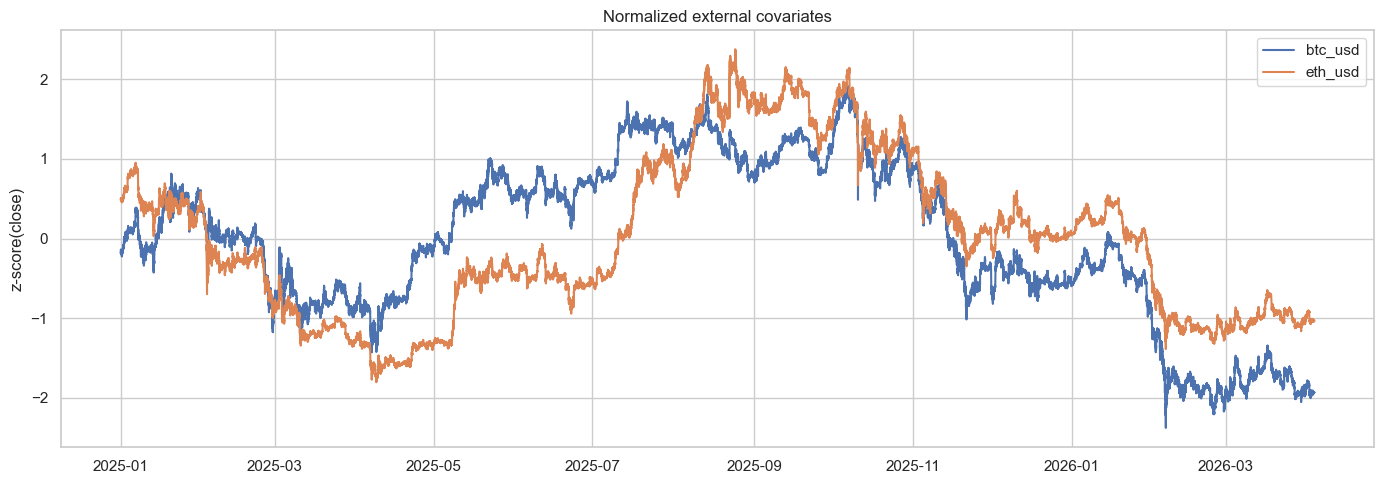

In [9]:
external_stats = (
    raw_external.covariates.groupby('series_id', as_index=False)
    .agg(
        rows=('timestamp_utc', 'size'),
        start=('timestamp_utc', 'min'),
        end=('timestamp_utc', 'max'),
        mean_close=('close', 'mean'),
    )
)
display(external_stats)

plot_cov = raw_external.covariates[['series_id', 'timestamp_utc', 'close']].dropna().copy()
plot_cov['z_close'] = plot_cov.groupby('series_id')['close'].transform(lambda s: (s - s.mean()) / s.std())

plt.figure(figsize=(14, 5))
for series_id, frame in plot_cov.groupby('series_id'):
    plt.plot(frame['timestamp_utc'], frame['z_close'], label=series_id, linewidth=1.5)
plt.title('Normalized external covariates')
plt.ylabel('z-score(close)')
plt.legend()
plt.tight_layout()
plt.show()

## Canonical layer

Теперь строим canonical dataset поверх raw layer. Это не новый источник данных, а стабильный нормализованный слой для всех следующих representations. Здесь происходят несколько вещей:

- filtering to `resolved_only=True` по текущей эвристике `end_date <= synced_at_utc`;
- согласование `markets` и `probabilities` по одному и тому же набору `market_id`;
- typed timestamps и более стабильная временная схема;
- stable `domain` field;
- weak `family_id` для sibling context и retrieval-style экспериментов;
- нормализация текстовых и tag-like полей;
- filesystem round-trip через `save(...)` и `from_parquet(...)`.

Ниже мы сразу сохраняем canonical snapshot в `research_notebooks/running_artefacts/canonical_dataset`.

In [19]:
canonical = CanonicalDatasetBuilder(raw_dataset=raw_dataset, raw_external=raw_external, resolved_only=True).build()
canonical_manifest = canonical.save(CANONICAL_CACHE_DIR)

print('Canonical cache:', CANONICAL_CACHE_DIR)
display(canonical.summary())
display(canonical_manifest)
display(canonical.markets[['market_id', 'question', 'domain', 'family_id', 'resolved']].head(10))

Canonical cache: /Users/sneddy/research/polymarket_research/research_notebooks/running_artefacts/canonical_dataset


,name,rows,cols
0,markets,2781,23
1,probabilities,48329908,7
2,external_covariates,263808,19


,file,rows,cols
0,markets.parquet,2781,23
1,probabilities.parquet,48329908,7
2,external_covariates.parquet,263808,19


,market_id,question,domain,family_id,resolved
0,546814,Will Zelenskyy wear a suit before July?,politics,politics::celebrities::zelenskyy wear suit before july,True
1,680392,US government shutdown Saturday?,politics,politics::congress|gov shutdown|parent for derivative::us government shutdown saturday,True
2,538932,Will Zohran Mamdani win the 2025 NYC mayoral election?,politics,politics::macro election 2|mayoral elections|nyc mayor::zohran mamdani win 2025 nyc mayoral,True
3,529278,Will Frances Fitzgerald win the Irish Presidential Election?,politics,politics::elections|global elections|ireland::frances fitzgerald win irish presidential election,True
4,519075,Will Hunor Kelemen win the Romanian presidential election?,politics,politics::global elections|politics|romania::hunor kelemen win romanian presidential election,True
5,538930,Will Curtis Sliwa win the 2025 NYC mayoral election?,politics,politics::macro election 2|mayoral elections|nyc mayor::curtis sliwa win 2025 nyc mayoral,True
6,519068,Will Nicușor Dan win the Romanian presidential election?,politics,politics::global elections|politics|romania::nicu or dan win romanian presidential,True
7,538931,Will Jim Walden win the 2025 NYC mayoral election?,politics,politics::macro election 2|mayoral elections|nyc mayor::jim walden win 2025 nyc mayoral,True
8,538929,Will Andrew Cuomo win the 2025 NYC mayoral election?,politics,politics::macro election 2|mayoral elections|nyc mayor::andrew cuomo win 2025 nyc mayoral,True
9,519066,Will George Simion win the Romanian presidential election?,politics,politics::global elections|politics|romania::george simion win romanian presidential election,True


## Canonical layer: family structure

`family_id` — это weak structural identifier. Он не является ground-truth family label, но уже полезен для sibling context и retrieval-style baselines.

,family_id,markets,domains
820,geopolitics::geopolitics|iran|israel::us next strike iran on february,28,geopolitics
1284,politics::culture|politics|tweet markets::elon musk post 300 319 tweets,21,politics
1285,politics::culture|politics|tweet markets::elon musk post 320 339 tweets,20,politics
821,geopolitics::geopolitics|iran|israel::us next strike iran on january,18,geopolitics
2068,technology::games|ligue 1|soccer::paris saint germain fc win on,18,technology
1286,politics::culture|politics|tweet markets::elon musk post 340 359 tweets,18,politics
1287,politics::culture|politics|tweet markets::elon musk post 360 379 tweets,15,politics
643,geopolitics::games|soccer|sports::bv borussia 09 dortmund win on,15,geopolitics
1283,politics::culture|politics|tweet markets::elon musk post 280 299 tweets,15,politics
1282,politics::culture|politics|tweet markets::elon musk post 260 279 tweets,14,politics


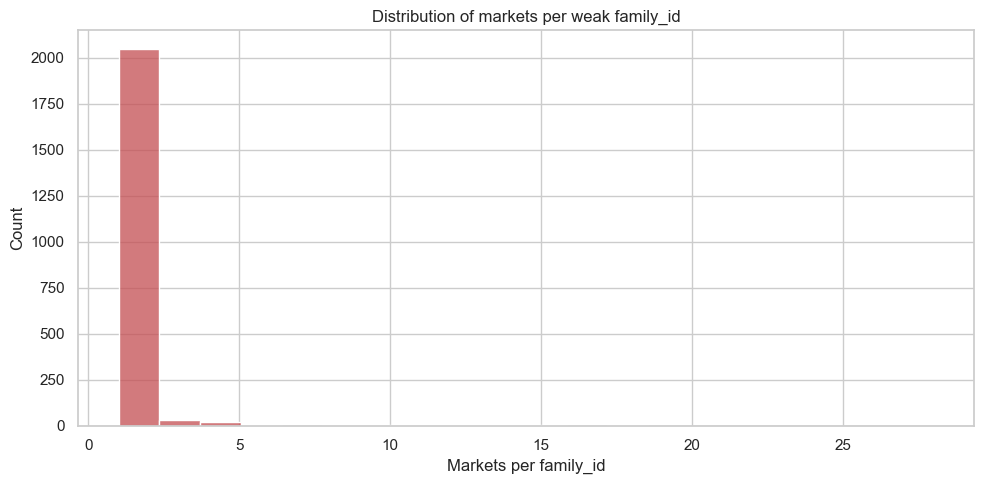

In [20]:
family_stats = (
    canonical.markets.groupby('family_id', as_index=False)
    .agg(
        markets=('market_id', 'nunique'),
        domains=('domain', lambda s: ', '.join(sorted(set(s)))),
    )
    .sort_values('markets', ascending=False)
)
display(family_stats.head(20))

plt.figure(figsize=(10, 5))
sns.histplot(family_stats['markets'], bins=20, color='#c44e52')
plt.title('Distribution of markets per weak family_id')
plt.xlabel('Markets per family_id')
plt.tight_layout()
plt.show()

## Filesystem workflow for clean layers

У clean layers есть симметричный lifecycle на файловой системе:

- raw external covariates можно сохранять и поднимать обратно;
- canonical dataset уже сохранён в постоянную директорию и его можно поднимать обратно;
- raw snapshot уже был сохранён как parquet раньше.

Ниже проверяем reload из сохранённого canonical cache.

In [21]:
canonical_reloaded = canonical.from_parquet(CANONICAL_CACHE_DIR)

filesystem_summary = pd.DataFrame([
    {
        'object': 'canonical_reloaded_markets',
        'rows': len(canonical_reloaded.markets),
        'cols': canonical_reloaded.markets.shape[1],
    },
    {
        'object': 'canonical_reloaded_probabilities',
        'rows': len(canonical_reloaded.probabilities),
        'cols': canonical_reloaded.probabilities.shape[1],
    },
])

display(pd.DataFrame([{'layer': 'canonical', 'path': str(CANONICAL_CACHE_DIR)}]))
display(filesystem_summary)

,layer,path
0,canonical,/Users/sneddy/research/polymarket_research/research_notebooks/running_artefacts/canonical_dataset


,object,rows,cols
0,canonical_reloaded_markets,2781,23
1,canonical_reloaded_probabilities,48329908,7


## Current architectural boundary

Сегодня clean data architecture заканчивается на этих слоях:

1. **Raw layer**
   - `markets`
   - `probabilities`
   - raw external covariates

2. **Canonical layer**
   - resolved filtering
   - internally consistent `markets` + `probabilities`
   - typed timestamps
   - stable `domain`
   - weak `family_id`
   - normalized text/tag-like fields
   - filesystem round-trip

Все benchmark-specific derived panels пока считаются **legacy layer** и живут отдельно в `/benchmarks`. Это сделано специально, чтобы `polymarket_research.data` оставался чистым foundation layer для дальнейшего развития.